# Logistic Regression(Wickrama W.M.K.E-IT25102219) — Adult Income Prediction

**Stage:** Final Evaluation - Implementation

**Problem:** Binary classification: predict whether a person earns `>50K` (1) or `<=50K` (0) from census attributes.

**Input:** `adult_processed.csv` produced by `group_pipeline.ipynb` (missing values imputed, duplicates and outliers removed, `education` dropped, categoricals one-hot encoded, numerics standardised).
## Why Logistic Regression suits this dataset
- Target is binary, so it is a natural fit for a probabilistic linear classifier.
- After one-hot encoding and scaling, the features are in the form logistic regression works best with.
- Coefficients are directly interpretable (odds ratios), useful for explaining *which* attributes drive income.
- Fast to train, so a large hyper-parameter grid with cross-validation is cheap.
- Class imbalance (~3:1) was flagged in the pipeline, so we evaluate with Precision / Recall / F1 / ROC-AUC, not accuracy alone.

## 1. Load the preprocessed dataset

In [5]:
from pathlib import Path
import pandas as pd

relative_data_path = Path("results") / "outputs" / "adult_processed.csv"
data_path = next(
    (parent / relative_data_path for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent / relative_data_path).is_file()),
    None,
)
if data_path is None:
    raise FileNotFoundError(
        f"Could not find {relative_data_path} from the current directory {Path.cwd()}. "
        "Run this notebook from inside the project directory."
    )

df = pd.read_csv(data_path)
print(df.shape)
df.head()

(32058, 83)


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,1.360450,1.712817,-0.41443,-0.232725,5.989283,-0.008462,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,-1.356863,-0.310543,-0.02313,-0.232725,5.989283,-2.567806,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,-0.402131,0.935970,-0.41443,-0.232725,5.989283,3.745241,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,-0.622454,0.637500,-0.02313,-0.232725,5.989283,-0.008462,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0.111955,0.928000,1.15077,-0.232725,5.989283,0.674029,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [25]:
import re
from pathlib import Path
import matplotlib.pyplot as plt

FIG_DIR = data_path.resolve().parents[2] / "results" / "eda_visualizations" / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not hasattr(plt, "_orig_show"):
    plt._orig_show = plt.show

def show_and_save(*args, **kwargs):
    for num in plt.get_fignums():
        fig = plt.figure(num)
        title = fig._suptitle.get_text() if fig._suptitle else (fig.axes[0].get_title() if fig.axes else "")
        slug = re.sub(r"[^a-zA-Z0-9]+", "_", title).strip("_").lower()[:50] or "figure"
        output_path = FIG_DIR / f"IT25102219_logistic_regression_{slug}.png"
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot: {output_path}")
    plt._orig_show(*args, **kwargs)

plt.show = show_and_save

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, classification_report)
sns.set_theme(style='whitegrid', palette='Set1')
RANDOM_STATE = 42

In [22]:
print(df['income'].value_counts(normalize=True).round(3).rename({0:'<=50K',1:'>50K'}))

income
<=50K    0.765
>50K     0.235
Name: proportion, dtype: float64


## 2. Train / test split
Stratified 80/20 split so both sets keep the same class ratio. The test set is touched **only for final reporting**. All tuning uses 5-fold stratified cross-validation on the training set.

In [9]:
X = df.drop(columns=['income']); 
y = df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Positive rate  train: %.3f  test: %.3f" % (y_train.mean(), y_test.mean()))

Train: (25646, 82) | Test: (6412, 82)
Positive rate  train: 0.235  test: 0.235


## 3. Evaluation helper
**Metrics and why**
- **Accuracy**: overall correctness, but misleading with ~3:1 imbalance (predicting all `<=50K` already gives ~75%).
- **Precision / Recall / F1 (class `>50K`)**: show how well the minority class is found. F1 is the main comparison metric.
- **ROC-AUC**: threshold-independent ranking quality.

**Validation method:** 5-fold Stratified CV on the training set (reports mean F1 / AUC), then a final hold-out test evaluation.

In [10]:
results = []
def evaluate(name, model, Xtr, Xte, threshold=0.5, note=""):
    cvres = cross_validate(model, Xtr, y_train, cv=cv, scoring=['f1','roc_auc'], n_jobs=-1)
    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xte)[:, 1]
    pred = (proba >= threshold).astype(int)
    row = {'Model': name,
           'CV F1': cvres['test_f1'].mean(), 'CV AUC': cvres['test_roc_auc'].mean(),
           'Test Acc': accuracy_score(y_test, pred), 'Test Prec': precision_score(y_test, pred),
           'Test Recall': recall_score(y_test, pred), 'Test F1': f1_score(y_test, pred),
           'Test AUC': roc_auc_score(y_test, proba), 'Note': note}
    results.append(row)
    print(f"{name}\n  CV  F1={row['CV F1']:.4f}  AUC={row['CV AUC']:.4f}"
          f"\n  Test Acc={row['Test Acc']:.4f} Prec={row['Test Prec']:.4f} Rec={row['Test Recall']:.4f} "
          f"F1={row['Test F1']:.4f} AUC={row['Test AUC']:.4f}")
    return model, pred, proba

## 4. Models trained (varieties)
| # | Variety | What changes |
|---|---------|--------------|
| M1 | Baseline | Default `LogisticRegression` (L2, C=1) |
| M2 | Class-weighted | `class_weight='balanced'` to handle imbalance |
| M3 | Feature-removal pre-processing | Drop `fnlwgt` (census sampling weight, not a personal attribute) |
| M4 | L1 feature selection | L1 penalty (`liblinear`, C=0.1) shrinks weak features to zero |
| M5 | GridSearchCV tuned | Search over C, penalty, solver, class_weight |
| M6 | Tuned + threshold tuning | M5 with decision threshold picked from CV predictions on train only |

### M1: Baseline

In [11]:
m1, p1, pr1 = evaluate("M1 Baseline (default)", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_train, X_test)


M1 Baseline (default)
  CV  F1=0.6517  AUC=0.9039
  Test Acc=0.8492 Prec=0.7280 Rec=0.5708 F1=0.6399 AUC=0.9059


### M2: Class-weighted

In [12]:
m2, p2, pr2 = evaluate("M2 class_weight=balanced",
                       LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
                       X_train, X_test, note="imbalance handling")

M2 class_weight=balanced
  CV  F1=0.6712  AUC=0.9039
  Test Acc=0.8110 Prec=0.5639 Rec=0.8591 F1=0.6809 AUC=0.9053


### M3: Pre-processing variant — remove `fnlwgt`

In [13]:
Xtr3, Xte3 = X_train.drop(columns=['fnlwgt']), X_test.drop(columns=['fnlwgt'])
m3, p3, pr3 = evaluate("M3 Drop fnlwgt + balanced",
                       LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
                       Xtr3, Xte3, note="feature removal")

M3 Drop fnlwgt + balanced
  CV  F1=0.6710  AUC=0.9037
  Test Acc=0.8113 Prec=0.5649 Rec=0.8532 F1=0.6797 AUC=0.9052


### M4: L1 regularisation (embedded feature selection)

In [14]:
import warnings;warnings.filterwarnings('ignore')
m4, p4, pr4 = evaluate("M4 L1 (C=0.1) + balanced",
                       LogisticRegression(penalty='l1', solver='liblinear', C=0.1, class_weight='balanced', random_state=RANDOM_STATE),
                       X_train, X_test, note="L1 sparsity")
print("  Features kept by L1:", int((m4.coef_ != 0).sum()), "of", X_train.shape[1])

M4 L1 (C=0.1) + balanced
  CV  F1=0.6697  AUC=0.9033
  Test Acc=0.8094 Prec=0.5611 Rec=0.8631 F1=0.6801 AUC=0.9043
  Features kept by L1: 33 of 82


### M5: Hyper-parameter tuning with GridSearchCV
Scoring = **F1** (the minority class matters). 5-fold stratified CV on the training set.

In [15]:
param_grid = [
    {'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear'], 'C': [0.01, 0.1, 1, 10, 100], 'class_weight': [None, 'balanced']},
    {'penalty': ['l1'], 'solver': ['liblinear'], 'C': [0.01, 0.1, 1, 10, 100], 'class_weight': [None, 'balanced']},
]
grid = GridSearchCV(LogisticRegression(max_iter=3000, random_state=RANDOM_STATE), param_grid,
                    scoring='f1', cv=cv, n_jobs=-1, return_train_score=False)
grid.fit(X_train, y_train)
n_combos = len(grid.cv_results_['params'])
print(f"Parameter combinations: {n_combos}  ->  total model fits: {n_combos * 5} (5-fold CV)")
print("Best params:", grid.best_params_)
print("Best CV F1 : %.4f" % grid.best_score_)

gs = pd.DataFrame(grid.cv_results_)[['param_penalty','param_solver','param_C','param_class_weight','mean_test_score','rank_test_score']]
gs.sort_values('rank_test_score').head(8)

Parameter combinations: 30  ->  total model fits: 150 (5-fold CV)
Best params: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 : 0.6718


,param_penalty,param_solver,param_C,param_class_weight,mean_test_score,rank_test_score
18,l2,lbfgs,100.0,balanced,0.671846,1
14,l2,lbfgs,10.0,balanced,0.671402,2
27,l1,liblinear,10.0,balanced,0.671355,3
19,l2,liblinear,100.0,balanced,0.671318,4
15,l2,liblinear,10.0,balanced,0.671310,5
29,l1,liblinear,100.0,balanced,0.671275,6
10,l2,lbfgs,1.0,balanced,0.671173,7
7,l2,liblinear,0.1,balanced,0.670968,8


In [16]:
m5, p5, pr5 = evaluate("M5 GridSearchCV best", grid.best_estimator_, X_train, X_test,
                       note=str(grid.best_params_))

M5 GridSearchCV best
  CV  F1=0.6718  AUC=0.9036
  Test Acc=0.8113 Prec=0.5644 Rec=0.8585 F1=0.6811 AUC=0.9050


Saved plot: C:\Users\Malan\Documents\Academic\Y2S1\AIML\AI Project\predicting-adult-income-level\results\eda_visualizations\models\IT25102219_logistic_regression_effect_of_c_on_cv_f1.png


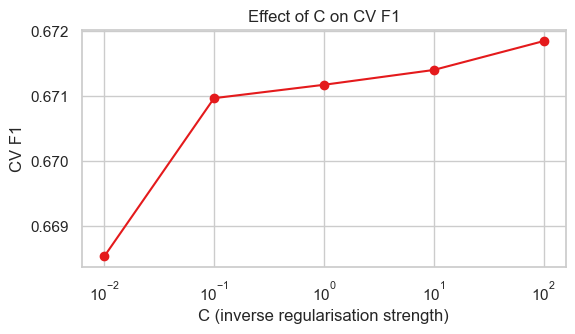

In [27]:
# Effect of C on CV F1 (best penalty/solver/class_weight family)
g = pd.DataFrame(grid.cv_results_)
g = g[(g.param_penalty == grid.best_params_['penalty']) & (g.param_class_weight == grid.best_params_['class_weight'])]
g = g.groupby('param_C')['mean_test_score'].max()
plt.figure(figsize=(6,3.5)); plt.semilogx(g.index.astype(float), g.values, marker='o')
plt.xlabel('C (inverse regularisation strength)'); plt.ylabel('CV F1'); plt.title('Effect of C on CV F1'); plt.tight_layout();
plt.show()

### M6: Tuned model + decision-threshold tuning
The threshold is chosen from **out-of-fold predictions on the training set**, never from the test set, to avoid leakage.

Best threshold from CV: 0.62 (OOF F1 = 0.6864)


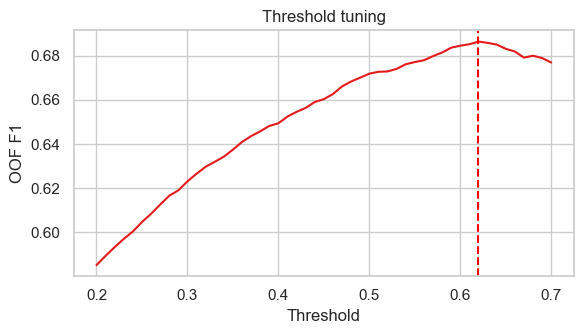

M6 Tuned + threshold
  CV  F1=0.6718  AUC=0.9036
  Test Acc=0.8358 Prec=0.6274 Rec=0.7395 F1=0.6789 AUC=0.9050


In [18]:
oof = cross_val_predict(grid.best_estimator_, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
ths = np.arange(0.20, 0.71, 0.01)
f1s = [f1_score(y_train, (oof >= t).astype(int)) for t in ths]
best_t = ths[int(np.argmax(f1s))]
print(f"Best threshold from CV: {best_t:.2f} (OOF F1 = {max(f1s):.4f})")
plt.figure(figsize=(6,3.5)); plt.plot(ths, f1s); plt.axvline(best_t, color='r', ls='--')
plt.xlabel('Threshold'); plt.ylabel('OOF F1'); plt.title('Threshold tuning'); plt.tight_layout(); plt.show()

m6, p6, pr6 = evaluate("M6 Tuned + threshold", grid.best_estimator_, X_train, X_test, threshold=best_t,
                       note=f"threshold={best_t:.2f}")

## 5. Comparison of all varieties

,CV F1,CV AUC,Test Acc,Test Prec,Test Recall,Test F1,Test AUC
Model,,,,,,,
M1 Baseline (default),0.6517,0.9039,0.8492,0.7280,0.5708,0.6399,0.9059
M2 class_weight=balanced,0.6712,0.9039,0.8110,0.5639,0.8591,0.6809,0.9053
M3 Drop fnlwgt + balanced,0.6710,0.9037,0.8113,0.5649,0.8532,0.6797,0.9052
M4 L1 (C=0.1) + balanced,0.6697,0.9033,0.8094,0.5611,0.8631,0.6801,0.9043
M5 GridSearchCV best,0.6718,0.9036,0.8113,0.5644,0.8585,0.6811,0.9050
M6 Tuned + threshold,0.6718,0.9036,0.8358,0.6274,0.7395,0.6789,0.9050


Best by Test F1: M5 GridSearchCV best


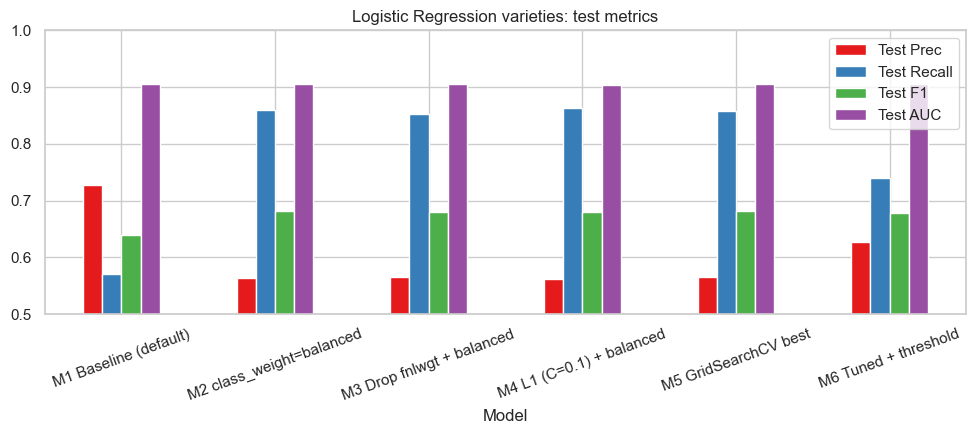

In [19]:
res = pd.DataFrame(results).set_index('Model')
display(res.drop(columns='Note').round(4))
best_name = res['Test F1'].idxmax()
print("Best by Test F1:", best_name)

ax = res[['Test Prec','Test Recall','Test F1','Test AUC']].plot(kind='bar', figsize=(10,4.5), rot=20)
ax.set_ylim(0.5, 1); ax.set_title('Logistic Regression varieties: test metrics'); plt.tight_layout(); plt.show()

## 6. Detailed evaluation of the best model

              precision    recall  f1-score   support

       <=50K       0.95      0.80      0.87      4907
        >50K       0.56      0.86      0.68      1505

    accuracy                           0.81      6412
   macro avg       0.76      0.83      0.77      6412
weighted avg       0.86      0.81      0.82      6412



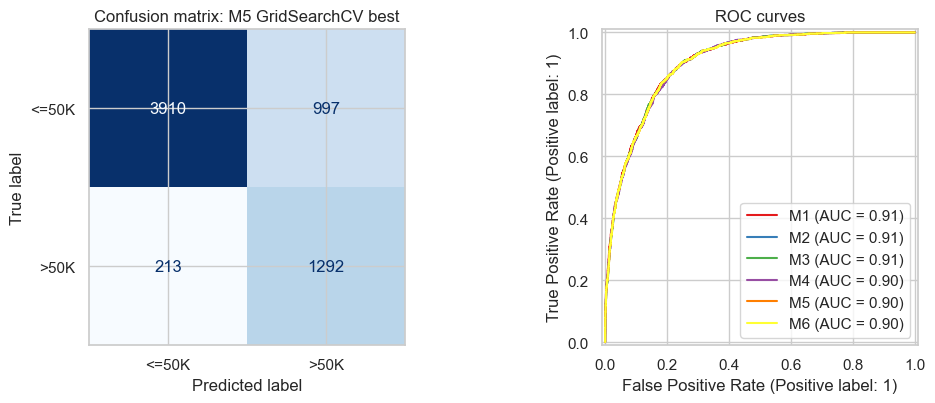

In [20]:

best_idx = list(res.index).index(best_name)
best_pred = [p1,p2,p3,p4,p5,p6][best_idx]
print(classification_report(y_test, best_pred, target_names=['<=50K','>50K']))
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ConfusionMatrixDisplay(confusion_matrix(y_test, best_pred), display_labels=['<=50K','>50K']).plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title(f'Confusion matrix: {best_name}')
for nm, pr in zip(res.index, [pr1,pr2,pr3,pr4,pr5,pr6]):
    RocCurveDisplay.from_predictions(y_test, pr, name=nm.split(' ')[0], ax=ax[1])
ax[1].set_title('ROC curves'); plt.tight_layout(); 
plt.show()

### Feature interpretation (tuned model coefficients)

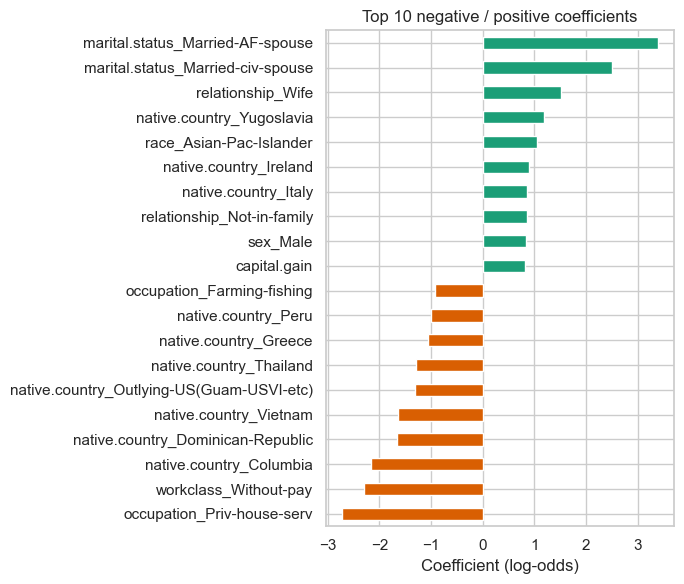

In [21]:
coef = pd.Series(grid.best_estimator_.coef_[0], index=X_train.columns).sort_values()
top = pd.concat([coef.head(10), coef.tail(10)])
plt.figure(figsize=(7,6)); top.plot(kind='barh', color=['#d95f02' if v<0 else '#1b9e77' for v in top])
plt.title('Top 10 negative / positive coefficients'); plt.xlabel('Coefficient (log-odds)'); plt.tight_layout(); plt.show()

## 7. Conclusion, limitations and improvements
**Conclusion**
- The default model (M1) has the highest accuracy (0.849) but recall on `>50K` is only 0.57, as expected with ~3:1 imbalance.
- `class_weight='balanced'` (M2) lifts recall to 0.86 and test F1 from 0.640 to 0.681, at the cost of precision (0.73 → 0.56).
- Removing `fnlwgt` (M3) and L1 selection (M4) change results only marginally, showing the model is stable and most signal comes from age, education, marital status, capital gain and hours worked.
- GridSearchCV (M5: L2, C=100, balanced) gave the best Test F1 (0.681), though only marginally above M2, so regularisation strength matters little here. Threshold tuning (M6, t=0.62) trades recall for precision (0.63 / 0.74) and recovers accuracy (0.836) with almost the same F1. ROC-AUC is ~0.905 for every variety, so ranking quality is unchanged and the differences come from the decision rule. Compare these against the group's other 5 models using Test F1 and ROC-AUC.

**Limitations**
- Logistic regression is linear, so it cannot capture feature interactions (e.g. age x education) unless added manually.
- ~3:1 imbalance remains; `class_weight` and thresholding are simple fixes only.
- Scaling was applied before the train/test split in the group pipeline (small leakage of mean/std). A `Pipeline` with the scaler fitted on train only would be stricter.
- Mode imputation can bias `workclass`/`occupation` towards the majority category.

**Possible improvements**
- Polynomial / interaction features, SMOTE or other resampling, `ElasticNet` penalty.
- Compare against tree-based models and calibrate probabilities.